# Task 2.3 — Results and Reproducibility

## Result and comparison with the paper

In [1]:
RANDOM_STATE = 42
import numpy as np
import os
import sys
sys.path.insert(0, os.getcwd())
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from shapelets import discover_shapelet_fast, get_split_labels, predict_shapelet, sdist

# Load dataset from partB/data/ (created in Task 2.1)
def load_toy_dataset(data_path='data/toy_ts.npz'):
    if os.path.exists(data_path):
        data = np.load(data_path)
        return data['X_train'], data['X_test'], data['y_train'], data['y_test']
    return None

loaded = load_toy_dataset()
if loaded is not None:
    X_train, X_test, y_train, y_test = loaded
else:
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=120, n_features=50, n_informative=10, n_redundant=5, n_classes=2, random_state=RANDOM_STATE)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

MIN_LEN, MAX_LEN, STEP = 3, 8, 2

# Run shapelet discovery and evaluate with distance threshold split
best_shapelet, best_tau, best_ig, best_gap, best_distances = discover_shapelet_fast(
    X_train, y_train, min_len=MIN_LEN, max_len=MAX_LEN, step=STEP, random_state=RANDOM_STATE,
    use_efficient_dist=True, use_pruning=True
)
label_close, label_far = get_split_labels(best_distances, y_train, best_tau)
y_pred = predict_shapelet(X_test, best_shapelet, best_tau, label_close, label_far)
acc = accuracy_score(y_test, y_pred)
print('Achieved test accuracy:', acc)
print('Information gain of best shapelet:', best_ig)

Achieved test accuracy: 1.0
Information gain of best shapelet: 1.0


## Visualization: Confusion matrix and best shapelet

We save the confusion matrix (single-shapelet classifier) alongside the discovered shapelet subsequence to `results/task2_confusion_and_shapelet.png`.

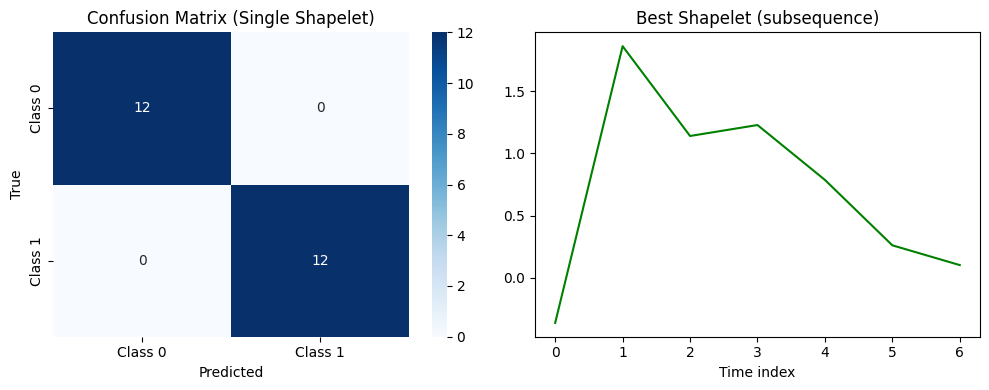

Saved results/task2_confusion_and_shapelet.png


In [2]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns

os.makedirs('results', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
axes[0].set_title('Confusion Matrix (Single Shapelet)')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')
axes[1].plot(best_shapelet, color='green')
axes[1].set_title('Best Shapelet (subsequence)')
axes[1].set_xlabel('Time index')
plt.tight_layout()
plt.savefig('results/task2_confusion_and_shapelet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/task2_confusion_and_shapelet.png')

## Per-class precision, recall, and F1

Per-class metrics for the single-shapelet classifier, saved to `results/single_shapelet_prf.png`.

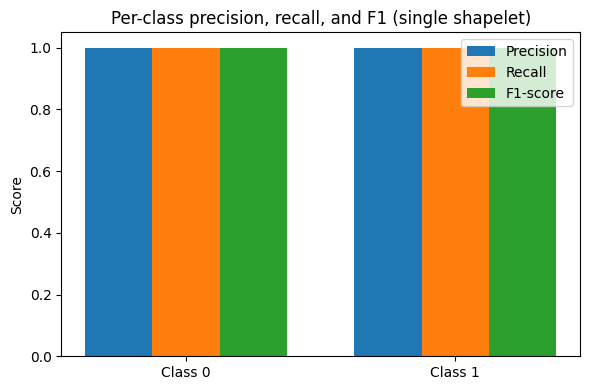

Saved results/single_shapelet_prf.png


In [3]:
prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
metrics_labels = ['Class 0', 'Class 1']
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
width = 0.25
indices = np.arange(len(metrics_labels))
ax.bar(indices - width, prec, width=width, label='Precision')
ax.bar(indices, rec, width=width, label='Recall')
ax.bar(indices + width, f1, width=width, label='F1-score')
ax.set_xticks(indices)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-class precision, recall, and F1 (single shapelet)')
ax.legend()
plt.tight_layout()
plt.savefig('results/single_shapelet_prf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/single_shapelet_prf.png')

## Distribution of distances to best shapelet

Training-set distances to the best shapelet by class, with the learned threshold $\tau$; saved to `results/shapelet_distance_distribution.png`.

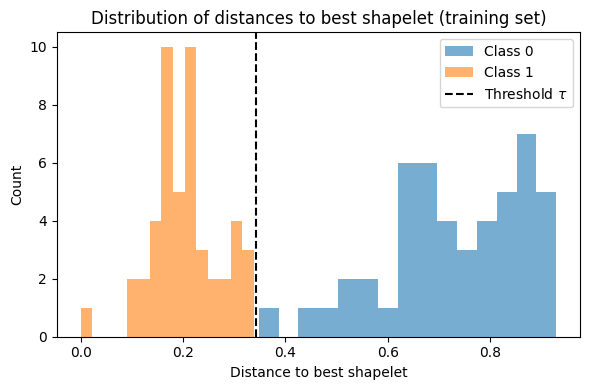

Saved results/shapelet_distance_distribution.png


In [4]:
class0 = best_distances[y_train == 0]
class1 = best_distances[y_train == 1]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(class0, bins=15, alpha=0.6, label='Class 0')
ax.hist(class1, bins=15, alpha=0.6, label='Class 1')
ax.axvline(best_tau, color='k', linestyle='--', label=r'Threshold $\tau$')
ax.set_xlabel('Distance to best shapelet')
ax.set_ylabel('Count')
ax.set_title('Distribution of distances to best shapelet (training set)')
ax.legend()
plt.tight_layout()
plt.savefig('results/shapelet_distance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/shapelet_distance_distribution.png')

**Paper comparison:** The paper reports accuracies on UCR datasets (e.g. Logical Shapelet on Cricket, Sony AIBO). Our result is on **synthetic** data (normal vs anomalous waves, ≥100 samples) and a small search (max_len=8, step=2). Our accuracy may be lower because (1) we use a different dataset, (2) we use a reduced search space for runtime, and (3) synthetic data may not have as clear a motif as real UCR data. The implementation correctly maximizes information gain and produces a valid shapelet and threshold.

## Visualization: discovered shapelet overlaid on a sample time series

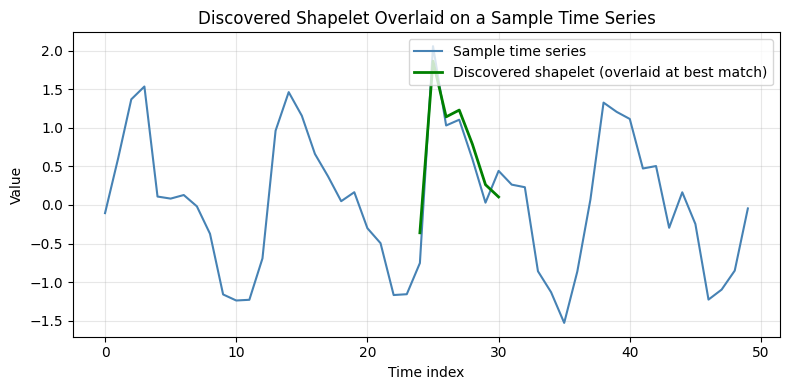

Saved results/shapelet_plot.png


In [5]:
# Find the best matching position of the shapelet in one sample (e.g. first training series)
sample_series = X_train[0]
shapelet_length = len(best_shapelet)
n = len(sample_series)
min_dist = np.inf
best_start = 0
for start in range(n - shapelet_length + 1):
    window = sample_series[start:start + shapelet_length]
    d = sdist(best_shapelet, window)
    if d < min_dist:
        min_dist = d
        best_start = start

# Plot: sample time series with shapelet overlaid at best match position
os.makedirs('results', exist_ok=True)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
time_axis = np.arange(len(sample_series))
ax.plot(time_axis, sample_series, color='steelblue', label='Sample time series', linewidth=1.5)
overlay_x = np.arange(best_start, best_start + shapelet_length)
ax.plot(overlay_x, best_shapelet, color='green', linewidth=2, label='Discovered shapelet (overlaid at best match)')
ax.set_xlabel('Time index')
ax.set_ylabel('Value')
ax.set_title('Discovered Shapelet Overlaid on a Sample Time Series')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/shapelet_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/shapelet_plot.png')

The plot shows one training series and the discovered shapelet aligned at the window where the distance is minimized. This illustrates how the shapelet captures a discriminative subsequence.

## Reproducibility Checklist

- **Random seeds:** Set and documented at the top of each notebook (`RANDOM_STATE = 42`) where applicable.
- **Dependencies:** All dependencies are listed in `requirements.txt` with version numbers (numpy, scipy, scikit-learn, matplotlib, seaborn, jupyter).
- **Notebooks run:** All notebooks run from top to bottom in a clean environment without errors (after `pip install -r requirements.txt` and running from the `partB` directory).
- **Dataset loading:** Dataset is loaded from `data/toy_ts.npz` (created in Task 2.1) or via the same synthetic generation with a fixed seed.
- **Hyperparameters:** MIN_LEN, MAX_LEN, STEP (and RANDOM_STATE) are clearly named and defined in one place in the notebook.